In [1]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 207.4 kB/s  0:05:07m0:00:0200:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 305.1/305.1 MB 200.9 kB/s  0:25:490:00:0200:41
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/creditcard.csv")

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

Training: (227845, 30)
Testing: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from pathlib import Path
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

In [9]:
rf_pipeline = Pipeline([
    ("sampler", RandomUnderSampler(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

rf_params = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.9804471022255565


In [13]:
best_rf = rf_grid.best_estimator_
best_rf

,steps,"[('sampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,replacement,False
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler


xgb_pipeline = Pipeline([
    ("sampler", RandomUnderSampler(random_state=42)),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

In [16]:
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", xgb_grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best CV ROC-AUC: 0.9818603163692377


In [17]:
best_xgb = xgb_grid.best_estimator_
best_xgb

,steps,"[('sampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,replacement,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


In [18]:


models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

    print(f"\n{name}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    ))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

ensemble_results = pd.DataFrame(results)
ensemble_results


Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56864
       Fraud       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

Confusion matrix:
[[54915  1949]
 [    9    89]]

XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962

Confusion matrix:
[[54508  2356]
 [    8    90]]


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.965626,0.043670,0.908163,0.083333,0.977774,0.701137
1,XGBoost,0.958499,0.036795,0.918367,0.070755,0.976517,0.680957


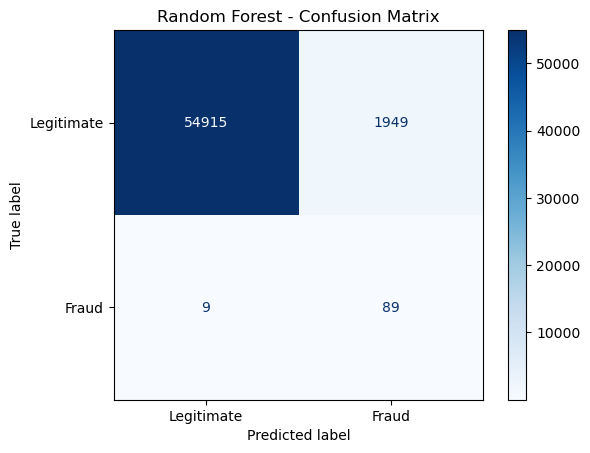


Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56864
       Fraud       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



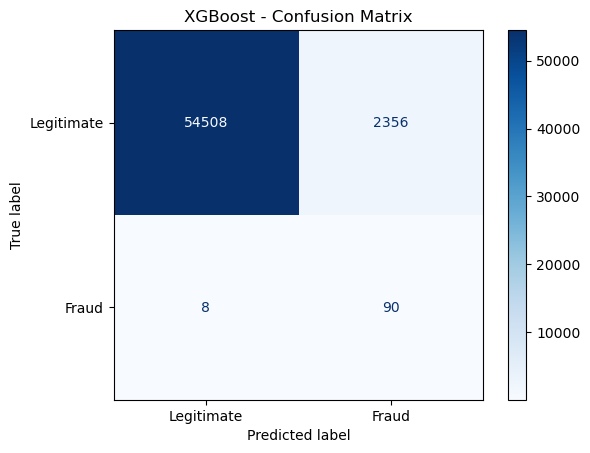


XGBoost
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.96      0.98     56962



In [19]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Legitimate", "Fraud"],
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    print(f"\n{name}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    ))

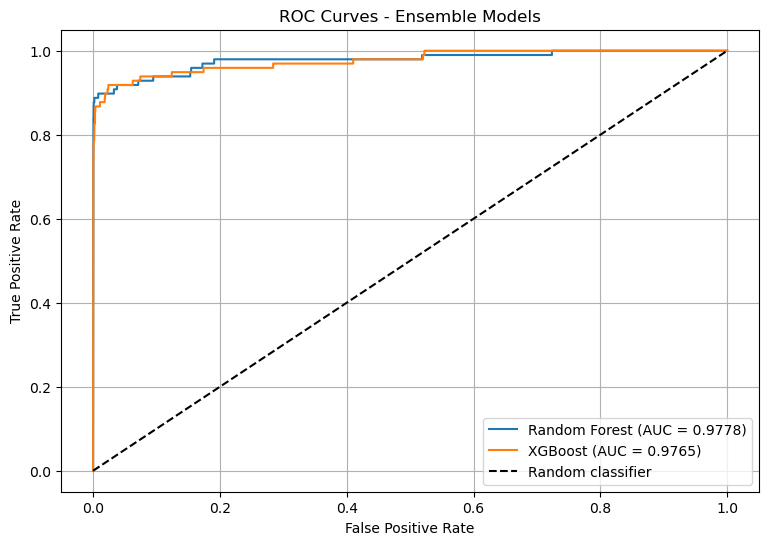

In [20]:
plt.figure(figsize=(9, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Ensemble Models")
plt.legend()
plt.grid(True)
plt.show()

In [32]:

voting_model = VotingClassifier(
    estimators=[
        ("rf", best_rf),
        ("xgb", best_xgb)
    ],
    voting="soft",
    n_jobs=1
)

In [45]:
weight_params = {
    "weights": [
        [1, 1],
        [2, 1],
        [3, 1],
        [4, 1],
        [5, 1],
        [1, 2],
        [1, 3],
        [1, 4],
        [1, 5],
        [2, 3],
        [3, 2],
        [4, 2],
        [2, 4],
        [3, 4],
        [4, 3]
    ]
}

In [46]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

voting_grid = GridSearchCV(
    estimator=voting_model,
    param_grid=weight_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

voting_grid.fit(X_train, y_train)

best_voting_model = voting_grid.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [47]:
print("Best weights:", voting_grid.best_params_["weights"])
print("Best CV ROC-AUC:", voting_grid.best_score_)

Best weights: [1, 3]
Best CV ROC-AUC: 0.9821255115081613


In [48]:
results = []

best_model = best_voting_model

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Best Soft Voting",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob)
})

print("Best Soft Voting")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

voting_results = pd.DataFrame(results)
voting_results

Best Soft Voting
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

Confusion matrix:
[[54611  2253]
 [    8    90]]


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Best Soft Voting,0.960307,0.038412,0.918367,0.07374,0.977299,0.693414


In [49]:
all_ensemble_results = pd.concat(
    [ensemble_results, voting_results],
    ignore_index=True
)

all_ensemble_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.965626,0.043670,0.908163,0.083333,0.977774,0.701137
1,XGBoost,0.958499,0.036795,0.918367,0.070755,0.976517,0.680957
2,Best Soft Voting,0.960307,0.038412,0.918367,0.073740,0.977299,0.693414


In [50]:
Path("results").mkdir(exist_ok=True)

all_ensemble_results.to_csv(
    "results/ensemble_results.csv",
    index=False
)

In [52]:
Path("models").mkdir(exist_ok=True)

joblib.dump(
    best_rf,
    "models/ensemble_random_forest.pkl"
)

joblib.dump(
    best_xgb,
    "models/xgboost.pkl"
)

joblib.dump(
    voting_model,
    "models/soft_voting.pkl"
)

print("Ensemble models saved successfully." )

Ensemble models saved successfully.
